Implement K-Means clustering on customer dataset. Determine the number of clusters using the elbow method.


Dataset link :
https://www.kaggle.com/code/heeraldedhia/kmeans-clustering-for-customer-data/input

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [12]:
data = pd.read_csv("D:/KAUSTUBH/LP3 Final/Mall_Customers.csv")

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### What is label encoding? How it is done?
### **Label Encoding**: 

**Label Encoding** is a technique used to convert categorical data (non-numeric labels) into a numerical format that machine learning algorithms can understand and work with. In **Label Encoding**, each unique category in the dataset is assigned a distinct integer (a label), typically starting from 0.

For example, if you have a column that contains categorical values like "Red," "Blue," and "Green," **Label Encoding** would assign each color a unique integer, like:

- "Red" → 0
- "Blue" → 1
- "Green" → 2

### **Why Use Label Encoding?**

Machine learning algorithms typically require **numeric data** to perform computations. Label encoding is a simple and effective way to convert categorical values into numeric form. This technique is especially useful when:

1. **The categories have a natural order** (ordinal data): For example, if you have a column for educational levels like "High School," "Bachelor's," and "Master's," the encoding should respect the order (e.g., 0 for High School, 1 for Bachelor's, 2 for Master's).
2. **The algorithm doesn’t depend on the magnitude of values**: For most machine learning models, such as decision trees, label encoding is not a problem because the model will treat the numeric values as categorical (it won’t assume that one value is “greater” than another, as it might with continuous data).

However, Label Encoding can be problematic with certain models, such as linear models or neural networks, when the categorical data doesn’t have an inherent ordinal relationship. For example, if you're encoding colors ("Red," "Blue," "Green"), there's no natural order, and the model might incorrectly assume a ranking based on the numerical encoding.

### **Steps in Label Encoding**:

1. **Identify the Categorical Column**: Select the column or feature in your dataset that contains categorical values.
2. **Assign Integer Values**: Assign a unique integer value to each distinct category in the column.
3. **Replace the Categorical Values**: Replace the original categorical values in the dataset with the corresponding integer values.
4. **Use the Encoded Data**: Once the column is encoded, the data can be fed into machine learning models.

### **Considerations with Label Encoding**:
1. **Ordinal Data**: If the categorical data is ordinal (i.e., the categories have a meaningful order), label encoding is appropriate. For example, in "Low," "Medium," "High," label encoding will reflect the natural order: Low = 0, Medium = 1, High = 2.
   
2. **Nominal Data**: If the categorical data is nominal (i.e., the categories don’t have any meaningful order), such as "Red," "Blue," "Green," label encoding could introduce an unintended ordinal relationship. In such cases, **One-Hot Encoding** might be a better choice.

3. **Impact on ML Models**: Some machine learning algorithms, like **Decision Trees**, **Random Forests**, or **Gradient Boosting**, can handle label-encoded data without issues. However, **linear models** (like **Logistic Regression** or **Linear Regression**) may treat label-encoded data as having a numerical relationship, leading to incorrect predictions. In such cases, **One-Hot Encoding** is often preferred.

In [13]:
# Convert the 'Gender' column to numerical values (e.g., Male = 0, Female = 1)
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])

In [14]:
# Select the relevant features for clustering
features = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

### Why Do We Need Scaling in Machine Learning?

In machine learning, **scaling** refers to the process of adjusting the range of numerical data to a standard scale. Scaling is important because many machine learning algorithms perform better when the features (or input variables) are on a similar scale. Here's why:

1. **Different Features Have Different Units and Ranges**: If you have a dataset with multiple features, they may have different units or ranges. For example, one feature might represent **age** (in years) ranging from 0 to 100, while another might represent **income** (in dollars) ranging from 0 to 1,000,000. The **income** feature will dominate the learning process because its values are much larger than those of **age**. This can lead to biased models.

2. **Algorithms Are Sensitive to Scale**: Some machine learning algorithms, such as **k-nearest neighbors (KNN)**, **support vector machines (SVM)**, and **gradient descent-based models** (like logistic regression or neural networks), depend on the distance between data points. If features are not scaled, the algorithm might give undue importance to features with larger values and ignore those with smaller values.

### Two Common Types of Scaling:

1. **Min-Max Scaling** (also called **Normalization**):
   - **What it does**: Min-Max scaling transforms the values of a feature so that they fall within a **specific range**, typically between 0 and 1.
   - **How it works**: It subtracts the minimum value of the feature and then divides by the range (max - min). The formula is:
     $$
     X_{\text{scaled}} = \frac{X - \text{min}(X)}{\text{max}(X) - \text{min}(X)}
     $$
   - **Why use it**: Min-Max scaling is useful when you need all features to have the same scale and when you know the range of the data. For instance, neural networks benefit from this scaling because their activation functions (like sigmoid or tanh) perform better when input values are between 0 and 1.

2. **Standard Scaling** (also called **Z-score Normalization** or **Standardization**):
   - **What it does**: Standard scaling transforms the values of a feature to have a **mean of 0** and a **standard deviation of 1**. This process doesn't bound the values to a specific range, but it ensures that each feature has equal importance.
   - **How it works**: The formula is:
     $$
     X_{\text{scaled}} = \frac{X - \mu}{\sigma}
     $$
     Where $\mu$ is the mean of the feature and $\sigma$ is the standard deviation.
   - **Why use it**: Standard scaling is useful when the distribution of your data has outliers, or when features have different units but the same range is not important. It works well for algorithms like **linear regression**, **logistic regression**, and **principal component analysis (PCA)**.

In [15]:
# Standardize the features for better clustering performance
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [16]:
# Determine the optimal number of clusters using the elbow method
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

### Inertia Explained:

- **Inertia** is the sum of squared distances between each data point and the **centroid** of the cluster it belongs to. A centroid is the center point of a cluster, which is the mean position of all the data points in that cluster.

- In simple terms, inertia measures how "tight" or "dense" the clusters are. The lower the inertia, the closer the data points are to their respective centroids, which indicates that the clusters are well-formed and compact.

### How is Inertia Calculated?

For each cluster, inertia is computed as the sum of squared differences between each data point and the centroid of that cluster. Mathematically:

$$
\text{Inertia} = \sum_{i=1}^{N} \sum_{j=1}^{K} \| x_i - c_j \|^2
$$

Where:
- $x_i$ is a data point,
- $c_j$ is the centroid of cluster \( j \),
- $N$ is the total number of data points,
- $K$ is the number of clusters,
- $\| x_i - c_j \|^2$ is the squared Euclidean distance between the data point and the centroid.

### Key Points About Inertia:

1. **Low Inertia**: A low inertia value indicates that the points in the clusters are close to their centroids, suggesting that the clustering is good and that the clusters are well-separated and compact.

2. **High Inertia**: A high inertia value suggests that the points are spread out and not well-clustered, indicating poor clustering.

3. **Comparing Different Numbers of Clusters**: Inertia is often used to determine the **optimal number of clusters** in methods like the **elbow method**. The idea is that as you increase the number of clusters, inertia will decrease because adding more clusters reduces the distance between data points and their centroids. However, after a certain point, the reduction in inertia becomes less significant. The **elbow point** is where the rate of decrease in inertia slows down, and it suggests the optimal number of clusters.

### Example:

Imagine you're using K-means clustering to cluster a set of data points into 3 clusters. After running the algorithm:
- The inertia might be 1000, meaning the total sum of squared distances between each data point and its cluster's centroid is 1000.
- If you try 4 clusters, inertia might decrease to 800, meaning the points are now closer to their centroids in the 4-cluster model.
- But if you try 5 clusters, the inertia might decrease to 750. The improvement is smaller, which suggests that 4 clusters might be a better choice than 5.

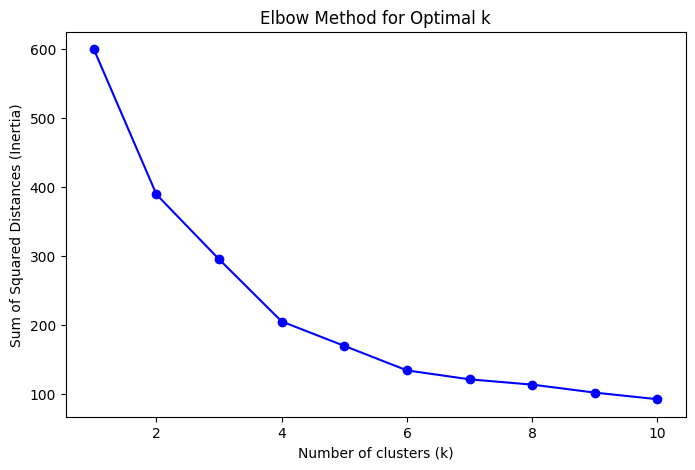

In [17]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', color='b')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Sum of Squared Distances (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [18]:
# From the elbow plot, choose the optimal number of clusters (e.g., k=4)
optimal_k = 4  # Adjust this based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = kmeans.fit_predict(scaled_features)

In [19]:
# Show the first few rows with cluster labels
print(data[['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].head())

   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1   19                  15                      39        2
1           2   21                  15                      81        2
2           3   20                  16                       6        2
3           4   23                  16                      77        2
4           5   31                  17                      40        2


In [20]:
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
print(cluster_centers)

         Age  Annual Income (k$)  Spending Score (1-100)
0  53.984615           47.707692               39.969231
1  32.875000           86.100000               81.525000
2  25.438596           40.000000               60.298246
3  39.368421           86.500000               19.578947


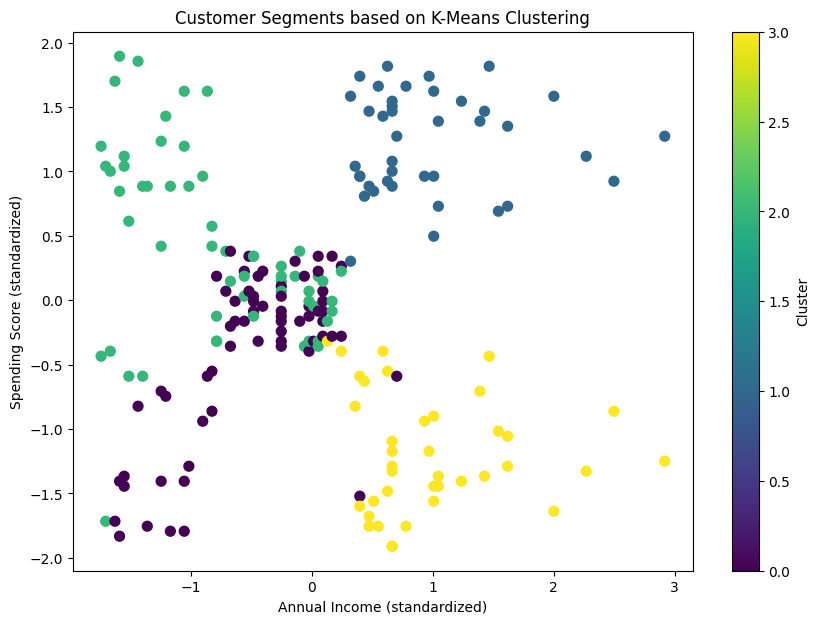

In [21]:
# Optional: Visualize the clusters (for 2D)
plt.figure(figsize=(10, 7))
plt.scatter(scaled_features[:, 1], scaled_features[:, 2], c=data['Cluster'], cmap='viridis', s=50)
plt.xlabel("Annual Income (standardized)")
plt.ylabel("Spending Score (standardized)")
plt.title("Customer Segments based on K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

### What is a Scatterplot?

A **scatterplot** (also known as a **scatter diagram** or **scatter chart**) is a graphical representation of two continuous variables where each point on the plot represents a pair of values. These points are plotted on a two-dimensional coordinate plane, with one variable shown on the **x-axis** (horizontal) and the other on the **y-axis** (vertical). Scatterplots are commonly used to investigate the relationship or correlation between two variables.

In a scatterplot:
- The **x-axis** represents the independent variable (or predictor).
- The **y-axis** represents the dependent variable (or response).
- Each dot represents one observation or data point, with the position of the dot determined by the values of the two variables.

### Example of Scatterplot:

Imagine you have a dataset that contains information about the **height** (in centimeters) and **weight** (in kilograms) of a group of people. In a scatterplot:
- The **x-axis** could represent height.
- The **y-axis** could represent weight.
Each point on the plot would correspond to an individual person, with their height on the x-axis and weight on the y-axis.

### How to Read a Scatterplot:

1. **Look at the Axes**:
   - The **x-axis** shows the values of the independent variable (e.g., height).
   - The **y-axis** shows the values of the dependent variable (e.g., weight).

2. **Identify the Data Points**:
   - Each **dot** on the scatterplot represents a single observation. The position of the dot corresponds to the values of the two variables for that observation.
   - If the dataset has many data points, the plot might look crowded, but the pattern formed by the points can still provide useful insights.

3. **Look for Patterns**:
   - **Positive Correlation**: If the points tend to rise together (i.e., as one variable increases, so does the other), this indicates a **positive correlation**. In the height vs. weight example, taller people tend to weigh more, so the points would form an upward trend.
   - **Negative Correlation**: If the points tend to go in opposite directions (i.e., as one variable increases, the other decreases), this indicates a **negative correlation**.
   - **No Correlation**: If the points are scattered randomly with no apparent pattern, this suggests **no correlation** between the variables.

4. **Look for Clusters or Groups**:
   - If the points are grouped together in certain areas, you might have subgroups or clusters of data that are more similar to each other than to others.
   - For example, people in one cluster might have similar heights and weights, while another cluster might represent people with different characteristics.

5. **Check for Outliers**:
   - **Outliers** are points that stand far away from the general pattern of the other points. They might indicate unusual or extreme observations. In a height vs. weight scatterplot, an outlier could be a very short person who is exceptionally heavy, or a very tall person who is exceptionally light.
   
6. **Examine the Trend**:
   - Sometimes scatterplots show a general **trend** or pattern. For example, the points might follow a straight line (linear relationship) or curve (non-linear relationship).
   - A **linear trend** means that the relationship between the two variables can be described with a straight line. A **curved trend** suggests a more complex, non-linear relationship.

7. **Fit a Line (Optional)**:
   - In some cases, a **regression line** or **line of best fit** might be added to the scatterplot. This line helps show the general trend of the data and is used to make predictions. It minimizes the distance between the data points and the line.

### Example Interpretation of a Scatterplot:

Imagine you have a scatterplot of hours studied (x-axis) and exam score (y-axis) for a group of students:

- If the points trend upward (forming a straight line or curve), this suggests that **more hours of study are associated with higher exam scores**, indicating a positive correlation.
- If the points are scattered with no clear pattern, this suggests that the amount of studying doesn't have a clear relationship with the exam scores.
- If the points trend downward, this would suggest a **negative correlation**, meaning that more studying might be associated with lower scores (though this would be unusual).
- If there are a few points far away from the others (e.g., one student who studied for many hours but scored very low), these points are **outliers**.